In [1]:
import numpy as np
import pandas as pd
import requests
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = Path.cwd().parent / "data"
print(DATA_PATH)

c:\ML_Projects\ML\fda-warning-letter-analysis\data


In [3]:
df = pd.read_csv(DATA_PATH / "warning_letters_full.csv")
df.head()

,letter_id,letter_issue_date,company_name,subject,letter_url,marcs_cms,Year,repeat_company,repeat_marcs,letter_text_raw,letter_text,llm_violations,llm_cfr_refs,llm_qa_domain,llm_severity,llm_summary_2s,llm_confidence
0,1,12/30/2025,Absolutely Natural,CGMP/Finished Pharmaceuticals/Adulterated,https://www.fda.gov/inspections-compliance-enf...,605871.0,2025,0,0,WARNING LETTER\nEU Natural Inc.\nMARCS-CMS 605...,WARNING LETTER\nEU Natural Inc.\nMARCS-CMS 605...,"[""Marketing dietary supplements with claims th...","[""21 U.S.C. \u00a7 321(g)(1)(B)"", ""21 U.S.C. \...",Regulatory Affairs / Product Classification,High,The company is marketing dietary supplements w...,High
1,2,12/29/2021,"Varigard, LLC",Unapproved New Drug Products Related to Corona...,https://www.fda.gov/inspections-compliance-enf...,616757.0,2021,0,0,"WARNING LETTER\nVarigard, LLC\nMARCS-CMS 61675...","WARNING LETTER\nVarigard, LLC\nMARCS-CMS 61675...","[""Marketing of unapproved new drug products (a...","[""21 U.S.C. 355(a) (FD&C Act Section 505(a))"",...",Regulatory Compliance & Labeling,High,"Varigard, LLC marketed unapproved new drug pro...",High
2,3,12/29/2021,Genesis Partnership Company SA,Drug Product/Misbranded,https://www.fda.gov/inspections-compliance-enf...,618953.0,2021,0,0,WARNING LETTER\nGenesis Partnership Company SA...,WARNING LETTER\nGenesis Partnership Company SA...,"[""The Bathletix HAND SANITIZER product is misb...","[""21 U.S.C. 352(i)(1)"", ""21 U.S.C. 331(a)""]",Labeling and Packaging,High,Genesis Partnership Company SA's Bathletix HAN...,High
3,4,12/28/2023,Woorilife & Health,CGMP/Finished Pharmaceuticals/Adulterated,https://www.fda.gov/inspections-compliance-enf...,672936.0,2023,0,0,WARNING LETTER\nWoorilife & Health\nMARCS-CMS ...,WARNING LETTER\nWoorilife & Health\nMARCS-CMS ...,"[""Failure to conduct at least one test to veri...","[""21 CFR 211.84(d)(1)"", ""21 CFR 211.22(a)""]",Quality System; Materials System; Laboratory C...,Critical - High Risk to Public Health,The firm failed to adequately test incoming hi...,High
4,5,12/23/2025,Tower Laboratories Ltd.,CGMP/Finished Pharmaceuticals/Adulterated,https://www.fda.gov/inspections-compliance-enf...,717456.0,2025,0,0,WARNING LETTER\nTower Laboratories Ltd.\nMARCS...,WARNING LETTER\nTower Laboratories Ltd.\nMARCS...,"[""Your firm failed to thoroughly investigate a...","[""21 CFR 211.192"", ""21 CFR 211.160(b)"", ""21 CF...",Laboratory Controls and Investigations,Critical,The FDA issued a Warning Letter to Tower Labor...,High


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   letter_id          650 non-null    int64  
 1   letter_issue_date  650 non-null    str    
 2   company_name       650 non-null    str    
 3   subject            650 non-null    str    
 4   letter_url         650 non-null    str    
 5   marcs_cms          650 non-null    float64
 6   Year               650 non-null    int64  
 7   repeat_company     650 non-null    int64  
 8   repeat_marcs       650 non-null    int64  
 9   letter_text_raw    650 non-null    str    
 10  letter_text        650 non-null    str    
 11  llm_violations     649 non-null    str    
 12  llm_cfr_refs       649 non-null    str    
 13  llm_qa_domain      649 non-null    str    
 14  llm_severity       649 non-null    str    
 15  llm_summary_2s     649 non-null    str    
 16  llm_confidence     650 non-null    st

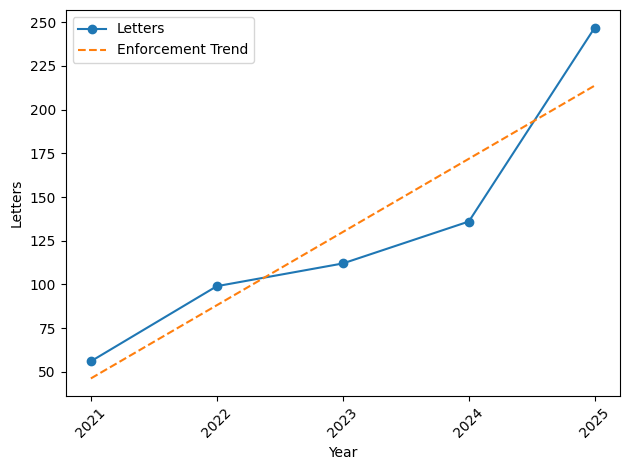

In [5]:
## Time Trends

data = df.groupby("Year").size().reset_index(name="count")

x = data["Year"]
y = data["count"]

fig, ax = plt.subplots()

ax.plot(x, y, marker="o", label="Count")

# Trend line
coef = np.polyfit(x, y, 1)
ax.plot(x, coef[0]*x + coef[1], "--", label="Trend")

ax.set_xlabel("Year")
ax.set_ylabel("Letters")

ax.set_xticks(sorted(df["Year"].unique()))
ax.tick_params(axis="x", rotation=45)

ax.legend(["Letters", "Enforcement Trend"])

plt.tight_layout()
plt.savefig("Time Trends.pdf", bbox_inches="tight")
plt.show()

In [6]:
##Clean LLM severity output
def normalize_severity(x):
    x = str(x).lower()

    if "critical" in x:
        return "Critical"
    elif "high" in x or "significant" in x:
        return "High"
    elif "major" in x:
        return "Medium"
    elif "low" in x or "warning" in x:
        return "Low"
    else:
        return "Other"

df["severity_clean"] = df["llm_severity"].apply(normalize_severity)
df["severity_clean"].value_counts()

severity_clean
Critical    449
High        192
Medium        4
Low           3
Other         2
Name: count, dtype: int64

In [7]:
## Add binary label for critical severity calssification
df["is_critical"] = df["severity_clean"].str.contains("critical", case=False).astype(int)

df["is_critical"].value_counts(normalize=True)

is_critical
1    0.690769
0    0.309231
Name: proportion, dtype: float64

In [8]:
#Companies with more than 1 unique marc-cms
result = (
    df.groupby("company_name")["marcs_cms"]
      .nunique()
      .loc[lambda x: x>1]
)
print("Companies with more than 1 unique marc-cms")
print(result)

Companies with more than 1 unique marc-cms
company_name
Amazon.com, Inc.    3
LCC Ltd.            2
Name: marcs_cms, dtype: int64


In [9]:
#Companies with more than 1 warning letter
result = (
    df.groupby("company_name")["letter_id"]
      .nunique()
      .loc[lambda x: x>1]
)
print("Companies with more than 1 warning letter")
print(result)

Companies with more than 1 warning letter
company_name
Amazon.com, Inc.                                      7
Avaria Health & Beauty Corp.                          2
Aytu Biopharma                                        2
Centaur Pharmaceuticals Private Ltd.                  2
Champaklal Maganlal Homeo Pharmacy Private Limited    2
ECI Pharmaceuticals, LLC                              2
Eli Lilly and Company                                 3
Fancystage Unipessoal, LDA                            2
Glenmark Pharmaceuticals Limited                      2
Glicerinas Industriales, S.A. de C.V.                 2
Intas Pharmaceuticals Limited                         2
LCC Ltd.                                              2
Name: letter_id, dtype: int64


In [10]:
#Severity distribution
df.groupby("repeat_company")["severity_clean"].value_counts()

repeat_company  severity_clean
0               Critical          429
                High              182
                Medium              4
                Low                 3
                Other               2
1               Critical           20
                High               10
Name: count, dtype: int64

In [11]:
#Severity by year
pd.crosstab(df["Year"], df["severity_clean"])

severity_clean,Critical,High,Low,Medium,Other
Year,,,,,
2021,34,21,1,0,0
2022,64,34,0,1,0
2023,78,31,1,0,2
2024,98,36,0,2,0
2025,175,70,1,1,0


In [12]:
##LLM CFR cleaning
#Convert CFRs in the list format
import ast

df["cfr_list"] = df["llm_cfr_refs"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df["cfr_list"] = df["cfr_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df["cfr_list"].head()

0    [21 U.S.C. § 321(g)(1)(B), 21 U.S.C. § 321(p),...
1    [21 U.S.C. 355(a) (FD&C Act Section 505(a)), 2...
2              [21 U.S.C. 352(i)(1), 21 U.S.C. 331(a)]
3              [21 CFR 211.84(d)(1), 21 CFR 211.22(a)]
4    [21 CFR 211.192, 21 CFR 211.160(b), 21 CFR par...
Name: cfr_list, dtype: object

In [13]:
#CFR list cleaning function
import re

def clean_cfr(ref):
    ref = ref.lower()

    # remove section symbol
    ref = ref.replace("§", "")

    # remove everything in brackets
    ref = re.sub(r"\(.*?\)", "", ref)

    # normalize spaces
    ref = re.sub(r"\s+", " ", ref)

    return ref.strip()

In [14]:
df["cfr_clean"] = df["cfr_list"].apply(
    lambda lst: [clean_cfr(x) for x in lst] if isinstance(lst, list) else []
)
df["cfr_clean"].head()

0    [21 u.s.c. 321, 21 u.s.c. 321, 21 u.s.c. 331, ...
1    [21 u.s.c. 355 ), 21 u.s.c. 352 ), 21 u.s.c. 3...
2                       [21 u.s.c. 352, 21 u.s.c. 331]
3                       [21 cfr 211.84, 21 cfr 211.22]
4    [21 cfr 211.192, 21 cfr 211.160, 21 cfr parts ...
Name: cfr_clean, dtype: object

In [15]:
#Separate and count CFR/USC 

df_cfr = df.explode("cfr_clean")
df_cfr["cfr_clean"].value_counts().head(20)


cfr_clean
21 u.s.c. 331               277
21 u.s.c. 352               238
21 u.s.c. 321               230
21 cfr 211.84               225
21 u.s.c. 331 )             221
21 u.s.c. 321 )             210
21 cfr 211.22               156
21 u.s.c. 351               137
21 u.s.c. 355               120
21 cfr 201.128              115
21 u.s.c. 355 )             112
21 cfr 211.165              107
21 cfr 211.100               98
21 cfr parts 210 and 211     83
21 u.s.c. 352 )              82
21 cfr 201.5                 81
21 cfr 211.34                80
21 cfr 211.192               76
21 cfr 211.166               74
21 cfr 201.115               73
Name: count, dtype: int64

In [16]:
#Count the unique value in clean column
unique_cfr = df_cfr["cfr_clean"].unique().tolist()
print(len(unique_cfr))

355


In [17]:
#Function for normalize cfr_clean

def normalize(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [18]:
#Reference extraction
def extract_reference(text):
    if pd.isna(text):
        return pd.Series([np.nan]*4)

    text = normalize(text)

    # USC
    usc = re.search(r'(\d+)\s*u\.?s\.?c\.?\s*\.?\s*(\d+[a-z\-]*)', text)
    if usc:
        return pd.Series(["USC", usc.group(1), usc.group(2), "section"])

    # CFR section 
    cfr_section = re.search( r'(\d+)\s*c\.?f\.?r\.?\s*\.?\s*(\d+(?:\.\d+)?)', text)
    if cfr_section:
        return pd.Series(["CFR", cfr_section.group(1), cfr_section.group(2), "section"])

    # CFR part 
    cfr_part = re.search(r'(\d+)\s*c\.?f\.?r\.?\s*part[s]?\s*(\d+)', text)
    if cfr_part:
        return pd.Series(["CFR", cfr_part.group(1), cfr_part.group(2), "part"])

    # FD&C Act section
    fdca = re.search(r'section\s*(\d+[a-z]?)\s*of the f', text)
    if fdca:
        return pd.Series(["FDCA", 21, fdca.group(1), "section"])

    # OTC monograph
    mono = re.search(r'm0?\d+', text)
    if mono:
        return pd.Series(["MONOGRAPH", None, mono.group(0).upper(), "monograph"])

    return pd.Series(["OTHER", None, None, None])

In [19]:
#Extract references, join with dataset

df_law_extr = df.join(
    df_cfr["cfr_clean"].apply(extract_reference)
        .set_axis(["source", "title", "number", "level"], axis=1)
)
df_law_extr.info()

<class 'pandas.DataFrame'>
Index: 4446 entries, 0 to 649
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   letter_id          4446 non-null   int64  
 1   letter_issue_date  4446 non-null   str    
 2   company_name       4446 non-null   str    
 3   subject            4446 non-null   str    
 4   letter_url         4446 non-null   str    
 5   marcs_cms          4446 non-null   float64
 6   Year               4446 non-null   int64  
 7   repeat_company     4446 non-null   int64  
 8   repeat_marcs       4446 non-null   int64  
 9   letter_text_raw    4446 non-null   str    
 10  letter_text        4446 non-null   str    
 11  llm_violations     4445 non-null   str    
 12  llm_cfr_refs       4445 non-null   str    
 13  llm_qa_domain      4445 non-null   str    
 14  llm_severity       4445 non-null   str    
 15  llm_summary_2s     4445 non-null   str    
 16  llm_confidence     4446 non-null   str   

In [20]:
#Represent CFR title as int
df_law_extr["title"] = pd.to_numeric(df_law_extr["title"], errors="coerce")
df_law_extr["title"].value_counts()

title
21.0    4242
15.0      38
42.0       6
27.0       1
Name: count, dtype: int64

In [21]:
#Check for source
df_law_extr["source"].value_counts()

source
CFR          2135
USC          2073
OTHER          95
FDCA           79
MONOGRAPH      50
Name: count, dtype: int64

In [22]:
#let`s dive more deep in CFR/USC references
df_cfr =df_law_extr[df_law_extr["source"] == "CFR"].copy()
df_usc =df_law_extr[df_law_extr["source"] == "USC"].copy()

In [23]:
#Extract CFR part
df_cfr["part"] = df_cfr["number"].str.extract(r"^(\d+)")
df_cfr["part"].value_counts()

part
211     1216
201      338
210      151
312      135
207       87
330       63
56        26
50        25
310       17
314       14
202       13
200        9
170        8
1271       6
181        6
212        5
570        4
352        3
1308       1
349        1
1          1
20         1
807        1
1100       1
101        1
4          1
820        1
Name: count, dtype: int64

In [24]:
#Same for UFC sections
df_usc["section"] = df_usc["number"].str.extract(r"^(\d+)")
df_usc["section"].value_counts()

section
331    525
321    472
352    330
355    327
351    177
353     74
360     57
41      24
381     20
374     14
342     12
57      11
348      8
262      6
387      6
45       3
841      2
843      2
361      1
356      1
301      1
Name: count, dtype: int64

In [25]:
# Let`s clean LLM QA domain based on specific words
def clean_domain(x):
    if not isinstance(x, str):
        return "Other"

    x = x.lower()

    scores = {
        "Regulatory": 0,
        "Quality": 0,
        "Manufacturing": 0,
        "Laboratory": 0,
        "Clinical": 0,
        "Labeling": 0
    }

    keywords = {
        "Regulatory": ["regulatory", "compliance"],
        "Quality": ["quality", "quality system", "quality unit"],
        "Manufacturing": ["manufactur", "material", "facility", "equipment"],
        "Laboratory": ["laboratory", "lab"],
        "Clinical": ["clinical", "research"],
        "Labeling": ["label", "packaging"]
    }

    for domain, words in keywords.items():
        for w in words:
            if w in x:
                scores[domain] += 1

    best = max(scores, key=scores.get)

    return best if scores[best] > 0 else "Other"

In [26]:
df["qa_domain_clean"] = df["llm_qa_domain"].apply(clean_domain)
df["qa_domain_clean"].value_counts()

qa_domain_clean
Regulatory       322
Quality          246
Laboratory        33
Clinical          18
Other             16
Manufacturing     13
Labeling           2
Name: count, dtype: int64

In [27]:
#Check how many domains are ambiguous
df[df["llm_qa_domain"].str.contains(",", na=False)][
    ["llm_qa_domain", "qa_domain_clean"]
].shape

(122, 2)

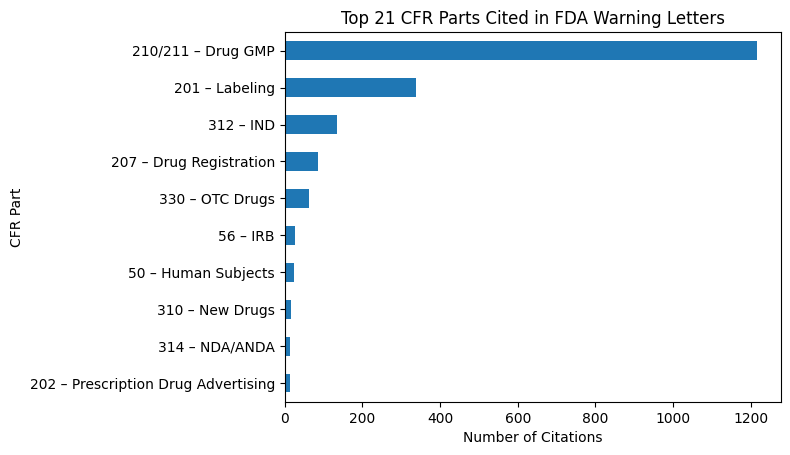

In [28]:
#Let`s check part distribution across CFR 21. Exclude part 210, because couldn`t be separated from 211`
df_cfr["part"] = df_cfr["part"].astype(int)
subset = df_cfr[df_cfr["part"] != 210]
cfr_part_counts = (subset["part"].value_counts().head(10).sort_values())
cfr_part_names = {
    211: "210/211 – Drug GMP",
    201: "201 – Labeling",
    210: "210 – Drug GMP (General)",
    312: "312 – IND",
    207: "207 – Drug Registration",
    330: "330 – OTC Drugs",
    56:  "56 – IRB",
    50:  "50 – Human Subjects",
    310: "310 – New Drugs",
    314: "314 – NDA/ANDA",
    202: "202 – Prescription Drug Advertising"
}

cfr_part_counts.index = cfr_part_counts.index.map(cfr_part_names)
#Plot
plt.figure()
cfr_part_counts.plot(kind="barh")
plt.xlabel("Number of Citations")
plt.ylabel("CFR Part")
plt.title("Top 21 CFR Parts Cited in FDA Warning Letters")
plt.savefig("Top 21 CFR parts.pdf", bbox_inches="tight")
plt.show()

In [29]:
#Go deeper in USC

df_usc = df_usc.drop(columns = ["letter_text"])
title_counts = (
    df_usc["title"]
    .value_counts()
    .sort_values())
title_counts

title
42.0       6
15.0      38
21.0    2029
Name: count, dtype: int64

In [30]:
usc_title_names = {
    21: "21 – Food, Drugs & Cosmetics",
    15: "15 – Commerce & Trade",
    42: "42 – Public Health & Welfare"
}
# Top 10 USC section
section_counts = (
    df_usc["number"]
    .value_counts().
        head(10)
    .sort_values())
section_counts

number
381      20
41       24
360      40
353      59
355h     79
351     177
355     247
352     330
321     472
331     525
Name: count, dtype: int64

In [31]:
#Check for unique parts in the list
df_usc[df_usc["number"].isin(["381", "41", "360", "353", "355h", "351", "355", "352", "321", "331"])]["title"].unique().tolist()

[21.0, 15.0]

In [32]:
#USC section names, simplified for regular person
usc_section_names = {
    "381": "381 – Import refusal",
    "41":  "15 USC 41 – Deceptive marketing",
    "360": "360 – Unregistered device",
    "353": "353 – Prescription misuse",
    "355h":"355h – Shortage reporting failure",
    "351": "351 – Adulterated Drugs",
    "355": "355 – Unapproved new drug",
    "352": "352 – Misbranded Drugs",
    "321": "321 – Incorrect product definition",
    "331": "331 – Prohibited Acts"
}

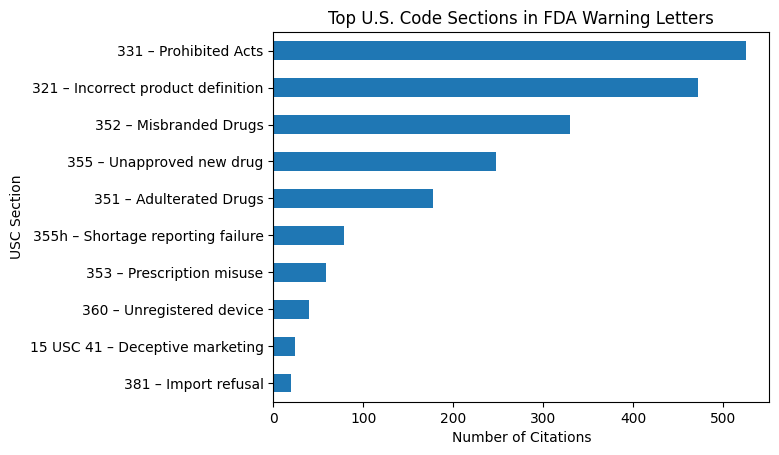

In [33]:

# map labels
section_counts.index = section_counts.index.map(usc_section_names)

plt.figure()
section_counts.plot(kind="barh")
plt.xlabel("Number of Citations")
plt.ylabel("USC Section")
plt.title("Top U.S. Code Sections in FDA Warning Letters")
plt.savefig("Top USC sections.pdf", bbox_inches="tight")
plt.show()


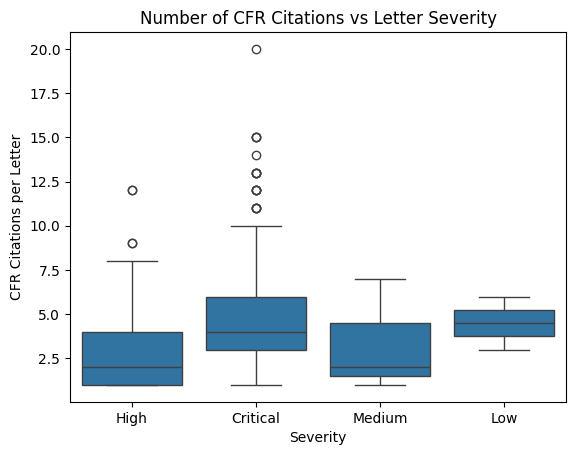

In [34]:
#Boxplot cfr citations vs severity
cfr_counts = (
    df_cfr
    .groupby("letter_id")
    .size()
    .reset_index(name="n_cfr")
)

cfr_counts = cfr_counts.merge(
    df[["letter_id","severity_clean"]],
    on="letter_id",
    how="left"
)

sns.boxplot(data=cfr_counts, x="severity_clean", y="n_cfr")
plt.title("Number of CFR Citations vs Letter Severity")
plt.xlabel("Severity")
plt.ylabel("CFR Citations per Letter")
plt.savefig(" CFR Citations vs Letter Severity.pdf", bbox_inches="tight")
plt.show()

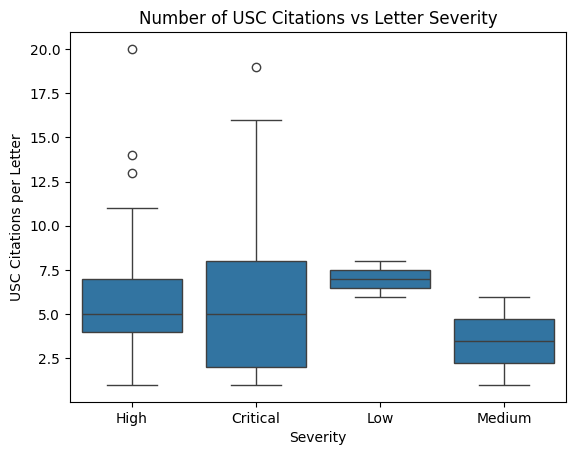

In [35]:
#Same fro USC

usc_counts = (
    df_usc
    .groupby("letter_id")
    .size()
    .reset_index(name="n_usc")
)

usc_counts = usc_counts.merge(
    df[["letter_id","severity_clean"]],
    on="letter_id",
    how="left"
)

sns.boxplot(data=usc_counts, x="severity_clean", y="n_usc")
plt.title("Number of USC Citations vs Letter Severity")
plt.xlabel("Severity")
plt.ylabel("USC Citations per Letter")
plt.savefig(" USC Citations vs Letter Severity.pdf", bbox_inches="tight")
plt.show()

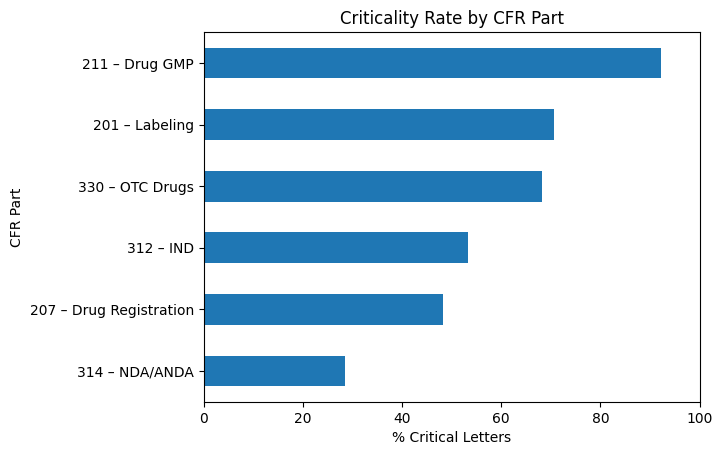

In [36]:
#Check which parts define criticality
top_parts = [211, 201, 312, 207, 330, 314]
subset = df_cfr[df_cfr["part"].isin(top_parts)]
subset.head()
part_crit = (
    subset.groupby("part")["is_critical"]
    .mean()
    .sort_values()
)
cfr_part_names = {
    211: "211 – Drug GMP",
    201: "201 – Labeling",
    210: "210 – Drug GMP (General)",
    312: "312 – IND",
    207: "207 – Drug Registration",
    330: "330 – OTC Drugs",
    56:  "56 – IRB",
    50:  "50 – Human Subjects",
    310: "310 – New Drugs",
    314: "314 – NDA/ANDA"
}
part_crit.index = part_crit.index.map(cfr_part_names)

plt.figure()
(part_crit * 100).plot(kind="barh")
plt.xlabel("% Critical Letters")
plt.ylabel("CFR Part")
plt.title("Criticality Rate by CFR Part")
plt.xlim(0,100)
plt.savefig(" CRit by CFR rate.pdf", bbox_inches="tight")
plt.show()

In [37]:
#Extract CFR point

def get_cfr_point(cfr):
    if not isinstance(cfr, str):
        return None
    
    m = re.search(r'\b\d+\.(\d+)', cfr)
    return m.group(1) if m else None

df_cfr["cfr_point"] = df_cfr["cfr_clean"].apply(get_cfr_point)

df_cfr["point"] = df_cfr["number"].apply(get_cfr_point)
df_cfr["point"] = pd.to_numeric(df_cfr["point"], errors="coerce").astype("Int64")

In [38]:
top_parts = df_cfr["part"].value_counts().head(10).index
df_crit_pt = df_cfr[df_cfr["part"].isin(top_parts)].copy()
point_crit = (
    df_crit_pt.groupby("part")["point"]
    .value_counts()
)

In [39]:
cfr_point_labels = {

# --- PART 50 – Protection of Human Subjects ---
(20):  "50.20 – Informed Consent Requirements",
(25):  "50.25 – Elements of Informed Consent",
(27):  "50.27 – Documentation of Consent",
(55):  "50.55 – IRB Review Requirements",
(52):  "50.52 – Clinical Investigation Exceptions",

# --- PART 56 – Institutional Review Boards ---
(108): "56.108 – IRB Functions & Operations",
(115): "56.115 – IRB Records",
(109): "56.109 – IRB Review of Research",
(113): "56.113 – IRB Suspension/Termination",
(104): "56.104 – Exempt Research",

# --- PART 201 – Labeling ---
(128): "201.128 – Intended Use",
(5):   "201.5 – Adequate Directions for Use",
(115): "201.115 – New Drug Labeling Exemption",
(66):  "201.66 – OTC Labeling Format",
(100): "201.100 – Prescription Drug Labeling",
(10):  "201.10 – Prominence of Required Info",
(327): "201.327 – OTC Drug Facts",
(15):  "201.15 – Minimum Labeling Size",
(61):  "201.61 – Established Name",

# --- PART 207 – Drug Registration & Listing ---
(49):  "207.49 – Listing Requirements",
(57):  "207.57 – Drug Listing Updates",
(77):  "207.77 – NDC Assignment",
(41):  "207.41 – Registration Timing",
(17):  "207.17 – Who Must Register",
(29):  "207.29 – Drug Listing Content",
(33):  "207.33 – Annual Updates",
(30):  "207.30 – Listing Format",

# --- PART 210 – GMP General ---
(1):   "210.1 – GMP Applicability",

# --- PART 211 – Finished Pharmaceutical GMP ---
(84):  "211.84 – Component Testing",
(22):  "211.22 – Quality Control Unit",
(165): "211.165 – Testing & Release",
(100): "211.100 – Written Procedures",
(34):  "211.34 – Consultant Qualification",
(192): "211.192 – Investigations",
(166): "211.166 – Stability Testing",
(160): "211.160 – Laboratory Controls",
(67):  "211.67 – Equipment Cleaning",
(113): "211.113 – Microbial Control",
(42):  "211.42 – Facility Design",
(188): "211.188 – Batch Records",
(194): "211.194 – Lab Records",
(68):  "211.68 – Automated Systems",
(137): "211.137 – Expiration Dating",
(180): "211.180 – General Records",
(63):  "211.63 – Equipment Design",
(25):  "211.25 – Personnel Qualification",
(198): "211.198 – Complaint Files",
(56):  "211.56 – Sanitation",
(110): "211.110 – In-Process Controls",
(167): "211.167 – Special Testing",
(58):  "211.58 – Building Maintenance",
(186): "211.186 – Master Production Record",
(101): "211.101 – Charge-In of Components",
(125): "211.125 – Labeling Issuance",
(94):  "211.94 – Drug Product Containers",
(170): "211.170 – Reserve Samples",
(182): "211.182 – Equipment Logs",
(28):  "211.28 – Personnel Responsibilities",
(46):  "211.46 – Ventilation",
(87):  "211.87 – Retesting of Components",

# --- PART 310 – New Drugs ---
(305): "310.305 – Postmarketing Safety Reports",
(545): "310.545 – Drug Efficacy Study (DESI)",
(527): "310.527 – OTC Conditions",
(548): "310.548 – Drug Products Withdrawn",

# --- PART 312 – IND ---
(2):   "312.2 – IND Applicability",
(60):  "312.60 – Investigator Responsibilities",
(20):  "312.20 – IND Requirements",
(40):  "312.40 – IND Activation",
(62):  "312.62 – Investigator Recordkeeping",
(66):  "312.66 – IRB Assurance",
(3):   "312.3 – Definitions",
(305): "312.305 – Expanded Access",
(33):  "312.33 – Annual Reports",
(50):  "312.50 – Sponsor Responsibilities",
(52):  "312.52 – Investigator Transfer",
(57):  "312.57 – Sponsor Recordkeeping",
(58):  "312.58 – Sponsor Inspection",
(69):  "312.69 – Investigator Noncompliance",
(7):   "312.7 – Promotion Restrictions",

# --- PART 314 – NDA / ANDA ---
(81):  "314.81 – Postmarketing Reports",
(3):   "314.3 – Definitions",
(50):  "314.50 – NDA Content",

# --- PART 330 – OTC Drugs ---
(1):   "330.1 – OTC General Conditions"
}


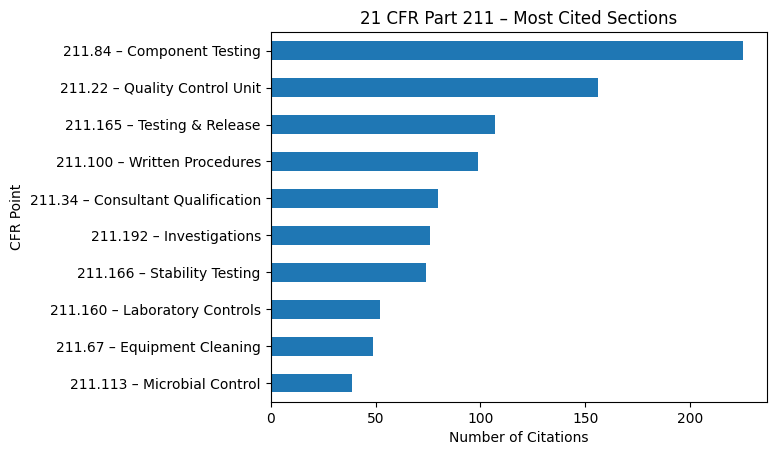

In [40]:
subset = df_cfr[df_cfr["part"] ==211]

cfr_211_label = {
(84):  "211.84 – Component Testing",
(22):  "211.22 – Quality Control Unit",
(165): "211.165 – Testing & Release",
(100): "211.100 – Written Procedures",
(34):  "211.34 – Consultant Qualification",
(192): "211.192 – Investigations",
(166): "211.166 – Stability Testing",
(160): "211.160 – Laboratory Controls",
(67):  "211.67 – Equipment Cleaning",
(113): "211.113 – Microbial Control",
(42):  "211.42 – Facility Design",
(188): "211.188 – Batch Records",
(194): "211.194 – Lab Records",
(68):  "211.68 – Automated Systems",
(137): "211.137 – Expiration Dating",
(180): "211.180 – General Records",
(63):  "211.63 – Equipment Design",
(25):  "211.25 – Personnel Qualification",
(198): "211.198 – Complaint Files",
(56):  "211.56 – Sanitation",
(110): "211.110 – In-Process Controls",
(167): "211.167 – Special Testing",
(58):  "211.58 – Building Maintenance",
(186): "211.186 – Master Production Record",
(101): "211.101 – Charge-In of Components",
(125): "211.125 – Labeling Issuance",
(94):  "211.94 – Drug Product Containers",
(170): "211.170 – Reserve Samples",
(182): "211.182 – Equipment Logs",
(28):  "211.28 – Personnel Responsibilities",
(46):  "211.46 – Ventilation",
(87):  "211.87 – Retesting of Components"}

point_counts = (
        subset["point"]
        .value_counts()
        .head(10)          # top 10 points per part
        .sort_values()
    )
point_counts.index = point_counts.index.map(cfr_211_label)
plt.figure()
point_counts.plot(kind="barh")
plt.xlabel("Number of Citations")
plt.ylabel("CFR Point")
plt.title(f"21 CFR Part 211 – Most Cited Sections")
plt.savefig("Part 211 most cited section.pdf", bbox_inches="tight")
plt.show()


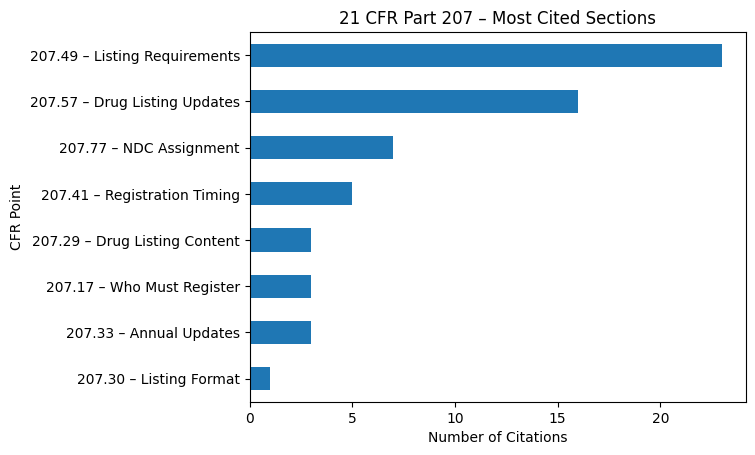

In [41]:
subset = df_cfr[df_cfr["part"] ==207]

cfr_207_label = {
(49):  "207.49 – Listing Requirements",
(57):  "207.57 – Drug Listing Updates",
(77):  "207.77 – NDC Assignment",
(41):  "207.41 – Registration Timing",
(17):  "207.17 – Who Must Register",
(29):  "207.29 – Drug Listing Content",
(33):  "207.33 – Annual Updates",
(30):  "207.30 – Listing Format"}

point_counts = (
        subset["point"]
        .value_counts()
        .head(10)          # top 10 points per part
        .sort_values()
    )
point_counts.index = point_counts.index.map(cfr_207_label)
plt.figure()
point_counts.plot(kind="barh")
plt.xlabel("Number of Citations")
plt.ylabel("CFR Point")
plt.title(f"21 CFR Part 207 – Most Cited Sections")
plt.savefig("Part 207 most cited section.pdf", bbox_inches="tight")
plt.show()

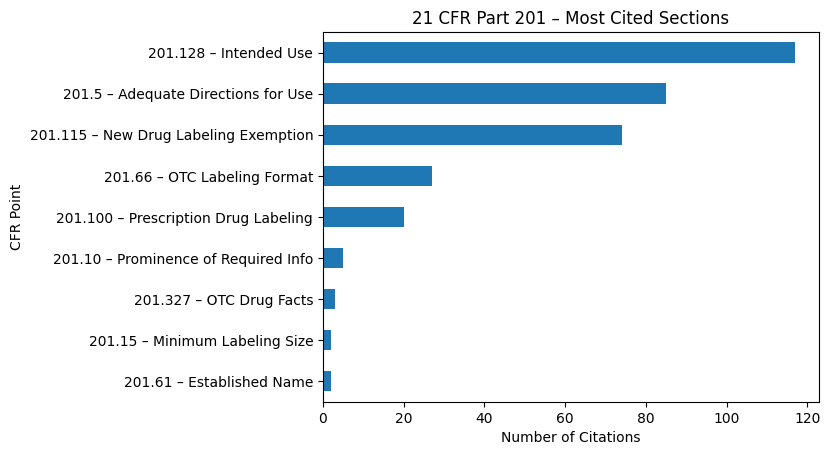

In [42]:
subset = df_cfr[df_cfr["part"] ==201]

cfr_201_label = {
(128): "201.128 – Intended Use",
(5):   "201.5 – Adequate Directions for Use",
(115): "201.115 – New Drug Labeling Exemption",
(66):  "201.66 – OTC Labeling Format",
(100): "201.100 – Prescription Drug Labeling",
(10):  "201.10 – Prominence of Required Info",
(327): "201.327 – OTC Drug Facts",
(15):  "201.15 – Minimum Labeling Size",
(61):  "201.61 – Established Name",}

point_counts = (
        subset["point"]
        .value_counts()
        .head(10)          # top 10 points per part
        .sort_values()
    )
point_counts.index = point_counts.index.map(cfr_201_label)
plt.figure()
point_counts.plot(kind="barh")
plt.xlabel("Number of Citations")
plt.ylabel("CFR Point")
plt.title(f"21 CFR Part 201 – Most Cited Sections")
plt.savefig("Part 201 most cited section.pdf", bbox_inches="tight")
plt.show()

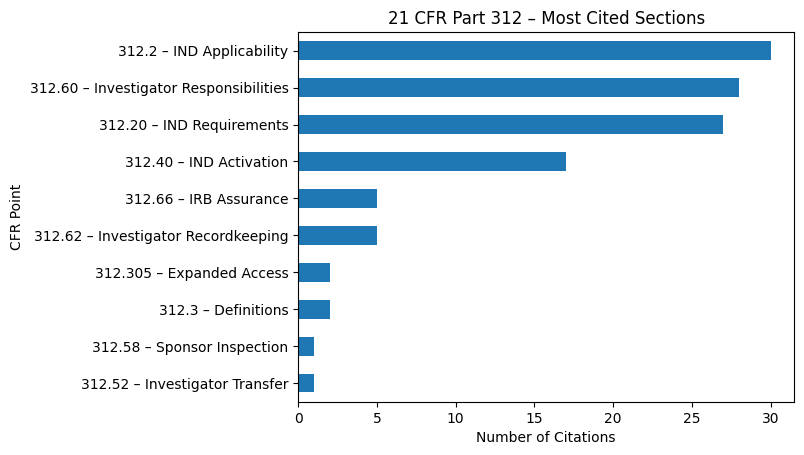

In [43]:
subset = df_cfr[df_cfr["part"] ==312]

cfr_312_label = {
(2):   "312.2 – IND Applicability",
(60):  "312.60 – Investigator Responsibilities",
(20):  "312.20 – IND Requirements",
(40):  "312.40 – IND Activation",
(62):  "312.62 – Investigator Recordkeeping",
(66):  "312.66 – IRB Assurance",
(3):   "312.3 – Definitions",
(305): "312.305 – Expanded Access",
(33):  "312.33 – Annual Reports",
(50):  "312.50 – Sponsor Responsibilities",
(52):  "312.52 – Investigator Transfer",
(57):  "312.57 – Sponsor Recordkeeping",
(58):  "312.58 – Sponsor Inspection",
(69):  "312.69 – Investigator Noncompliance",
(7):   "312.7 – Promotion Restrictions",}

point_counts = (
        subset["point"]
        .value_counts()
        .head(10)          # top 10 points per part
        .sort_values()
    )
point_counts.index = point_counts.index.map(cfr_312_label)
plt.figure()
point_counts.plot(kind="barh")
plt.xlabel("Number of Citations")
plt.ylabel("CFR Point")
plt.title(f"21 CFR Part 312 – Most Cited Sections")
plt.savefig("Part 312 most cited section.pdf", bbox_inches="tight")
plt.show()